In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error

# --- RDKit Chemistry ---
import rdkit.Chem as Chem
from rdkit import DataStructs, RDLogger
from rdkit.Chem import AllChem, Crippen, Descriptors, rdMolDescriptors
from rdkit.Chem.MolStandardize import rdMolStandardize
from rdkit.Chem.Scaffolds import MurckoScaffold

RDLogger.DisableLog("rdApp.*")

# --- Pytorch ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.data import Dataset
from torch_geometric.nn import GINConv, GCNConv, GATConv, global_add_pool, global_max_pool, global_mean_pool


# --- Visualization ---
import matplotlib.pyplot as plt
import umap.umap_ as umap

from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

In [34]:
raw = pd.read_csv(r"../csv/JAK2.csv", sep=";", low_memory=False)

In [35]:
raw['Standard Type'].value_counts()

Standard Type
IC50                                    19301
k_off                                   14112
kon                                     14112
Ki                                       4644
Inhibition                               1943
Activity                                  733
Kd                                        491
Residual Activity                         316
EC50                                      313
% Control                                 108
Ratio IC50                                 45
INH                                        36
% of control                               27
GI50                                       26
Delta Tm                                   25
fIC50                                      13
% of inhibition                            12
Residual activity                           9
deltaH                                      7
deltaG                                      7
-TdeltaS                                    7
FC                  

In [36]:
df = raw[raw['Standard Type']=='IC50'].copy()

In [37]:
print(f"The shape of the dataset is {df.shape}\n")
print(df.info())

The shape of the dataset is (19301, 48)

<class 'pandas.core.frame.DataFrame'>
Index: 19301 entries, 2 to 56316
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          19301 non-null  object 
 1   Molecule Name               625 non-null    object 
 2   Molecule Max Phase          593 non-null    float64
 3   Molecular Weight            19269 non-null  float64
 4   #RO5 Violations             19249 non-null  float64
 5   AlogP                       19249 non-null  float64
 6   Compound Key                19301 non-null  object 
 7   Smiles                      19269 non-null  object 
 8   Standard Type               19301 non-null  object 
 9   Standard Relation           19122 non-null  object 
 10  Standard Value              19122 non-null  float64
 11  Standard Units              19122 non-null  object 
 12  pChEMBL Value               14160 non-null  float64


In [44]:
print(df['Standard Units'].value_counts())
df = df[df['Standard Units']=='nM'].copy()

df.dropna(subset=['Smiles', 'Standard Units', 'Standard Relation', 'Standard Value'], inplace=True)
print(df.shape)
print(df.info())

Standard Units
nM         19089
10^2 uM        1
Name: count, dtype: int64
(19089, 48)
<class 'pandas.core.frame.DataFrame'>
Index: 19089 entries, 2 to 56316
Data columns (total 48 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Molecule ChEMBL ID          19089 non-null  object 
 1   Molecule Name               620 non-null    object 
 2   Molecule Max Phase          588 non-null    float64
 3   Molecular Weight            19089 non-null  float64
 4   #RO5 Violations             19070 non-null  float64
 5   AlogP                       19070 non-null  float64
 6   Compound Key                19089 non-null  object 
 7   Smiles                      19089 non-null  object 
 8   Standard Type               19089 non-null  object 
 9   Standard Relation           19089 non-null  object 
 10  Standard Value              19089 non-null  float64
 11  Standard Units              19089 non-null  object 
 12  pChEMB

In [45]:
df = df[df['Standard Relation']=="'='"].copy()
df.head()

,Molecule ChEMBL ID,Molecule Name,Molecule Max Phase,Molecular Weight,#RO5 Violations,AlogP,Compound Key,Smiles,Standard Type,Standard Relation,...,Document ChEMBL ID,Source ID,Source Description,Document Journal,Document Year,Cell ChEMBL ID,Properties,Action Type,Standard Text Value,Value
2,CHEMBL1231124,AZD-1480,2.0,348.77,0.0,3.01,BDBM294911,Cc1cc(Nc2nc(N[C@@H](C)c3ncc(F)cn3)ncc2Cl)[nH]n1,IC50,'=',...,CHEMBL5725835,37,BindingDB Patent Bioactivity Data,NaN,2018.0,NaN,NaN,NaN,NaN,0.700
3,CHEMBL2206059,NaN,NaN,359.46,0.0,2.32,BDBM50402074,CS(=O)(=O)NCc1nc2cnc3[nH]ccc3c2n1[C@@H]1C[C@H]...,IC50,'=',...,CHEMBL5725835,37,BindingDB Patent Bioactivity Data,NaN,2018.0,NaN,NaN,NaN,NaN,190.000
39,CHEMBL5888413,NaN,NaN,381.46,0.0,2.02,BDBM270872,CNS(=O)(=O)C[C@H]1CC[C@H](N(C)c2c([N+](=O)[O-]...,IC50,'=',...,CHEMBL5725576,37,BindingDB Patent Bioactivity Data,NaN,2018.0,NaN,NaN,NaN,NaN,1200.000
40,CHEMBL3960213,NaN,NaN,361.41,0.0,2.57,BDBM228768,CN(C(=O)Nc1ccc(C#N)cc1)[C@@H]1CCN(c2ncnc3[nH]c...,IC50,'=',...,CHEMBL3886703,37,BindingDB Patent Bioactivity Data,NaN,2016.0,NaN,NaN,NaN,NaN,0.550
42,CHEMBL1650736,NaN,NaN,433.42,0.0,2.03,16e,COc1cc(Nc2nc(N[C@@H](C)c3ncc(F)cn3)nc(N3CCOCC3...,IC50,'=',...,CHEMBL1649076,1,Scientific Literature,J Med Chem,2011.0,NaN,NaN,NaN,NaN,0.008


In [47]:
select_col = ['Smiles', 'Standard Value']
df = df[select_col]
df.head()

,Smiles,Standard Value
2,Cc1cc(Nc2nc(N[C@@H](C)c3ncc(F)cn3)ncc2Cl)[nH]n1,0.70
3,CS(=O)(=O)NCc1nc2cnc3[nH]ccc3c2n1[C@@H]1C[C@H]...,190.00
39,CNS(=O)(=O)C[C@H]1CC[C@H](N(C)c2c([N+](=O)[O-]...,1200.00
40,CN(C(=O)Nc1ccc(C#N)cc1)[C@@H]1CCN(c2ncnc3[nH]c...,0.55
42,COc1cc(Nc2nc(N[C@@H](C)c3ncc(F)cn3)nc(N3CCOCC3...,8.00


In [ ]:
def standardize(smiles):

    mol = Chem.MolFromSmiles(smiles)
    
    if mol is None:
        return None

    clean_mol = rdMolStandardize.Cleanup(mol)

    parent_clean_mol = rdMolStandardize.FragmentParent(clean_mol)

    uncharger = rdMolStandardize.Uncharger() 
    uncharged_parent_clean_mol = uncharger.uncharge(parent_clean_mol)

    te = rdMolStandardize.TautomerEnumerator() 
    taut_uncharged_parent_clean_mol = te.Canonicalize(uncharged_parent_clean_mol)

    return Chem.MolToSmiles(taut_uncharged_parent_clean_mol)

# df["Standardized Smiles"] = df["Smiles"].apply(standardize)

In [ ]:
# df.to_csv(r"data/JAK2_clean.csv", index=False)

# From Here

In [ ]:
# df = pd.read_csv("..\BACE1_Predictive_Modeling\BACE1_cleaned.csv")

In [ ]:
df = pd.read_csv(r"data/JAK2_clean.csv")
# select_col = ['Smiles', 'Standard Value', 'Standardized Smiles', 'pIC50']
# df = df[select_col]

def fp_scaffold(smiles):

    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return {
            "inchi_key": None,
            "scaffold": None,
            "MolWt": None,
            "NumHDonors": None,
            "NumHAcceptors": None,
            "TPSA": None,
            "NumRotatableBonds": None,
            "NumAromaticRings": None,
            "logP": None,
            "fp": None,
        }

    # Fingerprint
    fp_rdkit = AllChem.GetMorganFingerprintAsBitVect(
        mol, radius=2, nBits=2048
    )
    fp_numpy = np.zeros((2048,), dtype=np.int8)
    DataStructs.ConvertToNumpyArray(fp_rdkit, fp_numpy)

    # Scaffold
    scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    scaffold_smiles = Chem.MolToSmiles(scaffold)

    return {
            "inchi_key": Chem.MolToInchiKey(mol),
            "scaffold": scaffold_smiles,
            "MolWt": Descriptors.ExactMolWt(mol),
            "NumHDonors": rdMolDescriptors.CalcNumHBD(mol),
            "NumHAcceptors": rdMolDescriptors.CalcNumHBA(mol),
            "TPSA": rdMolDescriptors.CalcTPSA(mol),
            "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
            "NumAromaticRings": rdMolDescriptors.CalcNumAromaticRings(mol),
            "logP": Crippen.MolLogP(mol),
            "fp": fp_numpy,
        }
props = df["Standardized Smiles"].apply(fp_scaffold).apply(pd.Series)

df = pd.concat([df, props], axis=1)

df.rename(columns={'Standard Value': 'IC50'}, inplace=True)
df['pIC50'] = 9 - np.log10(df['IC50'].astype(float))

c:\Users\yashd\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [100]:
def remove_dupli_inchi(df_bak, dupli_inchis):
    
    dupli_inchi_bak = df_bak["inchi_key"].value_counts() != 1

    dupli_inchis = (df_bak["inchi_key"].value_counts())[dupli_inchi_bak].index

    for inchi in dupli_inchis:
        median_value = df_bak[df_bak["inchi_key"] == inchi]["IC50"].median()
        index = df_bak[df_bak["inchi_key"] == inchi].index[0]
        single_input = df_bak[df_bak["inchi_key"] == inchi].loc[[index]]
        single_input["inchi_key"] = median_value
        
        df_bak.drop(index=df_bak[df_bak["inchi_key"] == inchi].index, inplace=True)
        df_bak = pd.concat([df_bak, single_input], ignore_index=True)
    return df_bak.reset_index(drop=True)

dupli_inchi = df["inchi_key"].value_counts() != 1
dupli_inchis = (df["inchi_key"].value_counts())[dupli_inchi].index

df = remove_dupli_inchi(df, dupli_inchis)
len(df)

10314

In [101]:
df.describe()

,IC50,MolWt,NumHDonors,NumHAcceptors,TPSA,NumRotatableBonds,NumAromaticRings,logP,pIC50
count,1.031400e+04,10314.000000,10314.000000,10314.000000,10314.000000,10314.000000,10314.000000,10314.000000,1.031400e+04
mean,1.909699e+04,442.987715,2.031414,6.314718,108.639529,5.626818,3.194493,3.211639,inf
std,2.676106e+05,85.071496,0.951037,1.807641,26.854111,1.999579,0.809610,1.139106,NaN
min,0.000000e+00,160.063663,0.000000,0.000000,6.480000,0.000000,0.000000,-4.738060,1.602060e+00
25%,1.100000e+01,386.174276,1.000000,5.000000,89.610000,4.000000,3.000000,2.439270,6.259637e+00
50%,6.400000e+01,435.230411,2.000000,6.000000,107.910000,6.000000,3.000000,3.177700,7.193820e+00
75%,5.500000e+02,492.167754,3.000000,7.000000,126.270000,7.000000,4.000000,3.934360,7.958607e+00
max,2.500000e+07,1517.647864,22.000000,21.000000,599.220000,25.000000,7.000000,10.139600,inf


In [103]:
df = df[df['IC50'] > 0.0].copy()
df.reset_index(drop=True, inplace=True)
df.shape

(10310, 14)

In [105]:
scaffold_counts = (df['scaffold'].value_counts().reset_index())
scaffold_counts.columns = ['scaffold', 'count']

print(f'Length of the total unique scaffolds is {len(scaffold_counts)}')
target = len(df) * 0.7

cum_sum = scaffold_counts['count'].cumsum()
threshold = cum_sum.ge(target).idxmax()   

print(f"Threshold index: {threshold}")
print(f"Cumulative count: {cum_sum.iloc[threshold]}")

train_scaffold = scaffold_counts.iloc[:threshold+1]['scaffold'].tolist()
test_scaffold = scaffold_counts.iloc[threshold+1:]['scaffold'].tolist()

Length of the total unique scaffolds is 3853
Threshold index: 1035
Cumulative count: 7218


In [106]:
print(len(df[df['scaffold'].isin(train_scaffold)]), len(df[df['scaffold'].isin(test_scaffold)]))

7218 3092


In [118]:
# train_dataset = df[df['scaffold'].isin(train_scaffold)].reset_index(drop=True)
# test_dataset = df[df['scaffold'].isin(test_scaffold)].reset_index(drop=True)

from sklearn.model_selection import train_test_split

train_dataset, test_dataset = train_test_split(
    df,
    test_size=0.3,
    shuffle=True,
    random_state=42
)

train_dataset = train_dataset.reset_index(drop=True)
test_dataset = test_dataset.reset_index(drop=True)

In [119]:
len(train_dataset)

7217

In [58]:
# Convert the 'fp' column containing feature vectors into a 2D matrix
X_fp = np.vstack(train_dataset['fp'].values)

# Create UMAP instance
umap_model = umap.UMAP(n_components=2, random_state=42)

# Fit and transform
X_fp_umap = umap_model.fit_transform(X_fp)

print(X_fp_umap.shape)

train_dataset['UMAP_1'] = X_fp_umap[:, 0]
train_dataset['UMAP_2'] = X_fp_umap[:, 1]

c:\Users\yashd\anaconda3\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


(7221, 2)


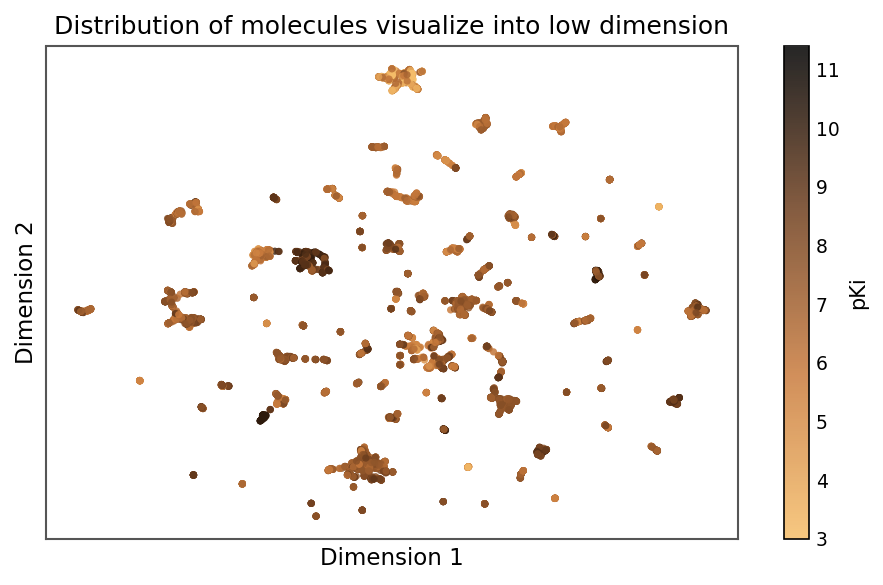

In [59]:
paper_cmap = LinearSegmentedColormap.from_list("paper_orange_black",
                                                            [
                                                                "#F6BE6A",   # light orange
                                                                "#C97B3D",   # brown-orange
                                                                "#70401F",   # dark brown
                                                                "#000000"    # black
                                                            ])

fig, ax = plt.subplots(figsize=(6, 4), dpi=150)
scatter = ax.scatter( train_dataset['UMAP_1'], train_dataset['UMAP_2'], c=train_dataset['pIC50'], cmap=paper_cmap, s=12, alpha=0.85, edgecolors='none')

ax.set_xlabel("Dimension 1",fontsize=11)
ax.set_ylabel("Dimension 2", fontsize=11)
ax.tick_params(axis='both', which='both', bottom=False, left=False, labelbottom=False, labelleft=False)

# Thin gray border
for spine in ax.spines.values():
    spine.set_color("#555555")
    spine.set_linewidth(1.0)
    
cbar = plt.colorbar(scatter, ax=ax, fraction=0.046, pad=0.06)
cbar.set_label("pKi", fontsize=10)
cbar.ax.tick_params(labelsize=9, length=0)
cbar.outline.set_linewidth(0.8)

plt.title("Distribution of molecules visualize into low dimension")
plt.tight_layout()
plt.savefig("plots/UMAP_Bioactivity_Projection.png", dpi=300, bbox_inches="tight")
plt.show()

In [120]:
def get_atom_bonds(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None, None
    mol = Chem.AddHs(mol)
    atoms = []
    for atm in mol.GetAtoms():
        atoms.append(np.array([ atm.GetAtomicNum() * 0.01,
                                atm.GetMass() * 0.01,
                                atm.GetDegree() * 0.01,
                                atm.GetFormalCharge(),
                                int(atm.GetIsAromatic()),
                                int(atm.GetNumRadicalElectrons())], dtype=np.float32))
    
    bonds = []  
    for bond in mol.GetBonds():
        bonds.append([bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()])
        bonds.append([bond.GetEndAtomIdx(), bond.GetBeginAtomIdx()])
        
    return np.array(atoms), np.array(bonds).transpose()

train_dataset[["atoms", "bonds"]] = train_dataset["Smiles"].apply(lambda x: pd.Series(get_atom_bonds(x)))
test_dataset[["atoms", "bonds"]] = test_dataset["Smiles"].apply(lambda x: pd.Series(get_atom_bonds(x)))

In [121]:
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataLoader

class GraphDataset(Dataset):
    def __init__(self, X, y, z):
        super().__init__()
        self.graphs = X.values
        self.targets = y.values.astype(float)
        self.fps = z

    def len(self):
        return len(self.graphs)

    def get(self, idx):
        x = torch.tensor(self.graphs[idx][0], dtype=torch.float)
        edge_index = torch.tensor(self.graphs[idx][1], dtype=torch.long)
        
        fps = torch.tensor(self.fps[idx], dtype=torch.float)

        y = torch.tensor([self.targets[idx]], dtype=torch.float)

        return Data(
            x=x,
            fps = fps,
            edge_index=edge_index,
            y=y
        )
        
train_dataset_pyg = GraphDataset(train_dataset[['atoms', 'bonds']], train_dataset['pIC50'], train_dataset['fp'])
test_dataset_pyg = GraphDataset(test_dataset[['atoms', 'bonds']], test_dataset['pIC50'], test_dataset['fp'])

train_loader = DataLoader(train_dataset_pyg, batch_size=256, shuffle=True)
test_loader = DataLoader(test_dataset_pyg, batch_size=256)

In [122]:
train_dataset_pyg[1]

Data(x=[71, 6], edge_index=[2, 150], y=[1], fps=[2048])

In [123]:
for x, fp, edge, y in train_dataset_pyg:
    print(x)
    print(fp)
    print(edge)
    print(y)
    break

('x', tensor([[0.0700, 0.1401, 0.0100, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0200, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0400, 0.0000, 0.0000, 0.0000],
        [0.0700, 0.1401, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.0700, 0.1401, 0.0200, 0.0000, 1.0000, 0.0000],
        [0.0600, 0.1201, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.0700, 0.1401, 0.0300, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.0600, 0.1201, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.0600, 0.1201, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.0600, 0.1201, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.1700, 0.3545, 0.0100, 0.0000, 0.0000, 0.0000],
        [0.0600, 0.1201, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.0600, 0.1201, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.0600, 0.1201, 0.0300, 0.0000, 1.0000, 0.0000],
        [0.0600, 0.1201, 0.0300, 0.0000, 1.0000, 0.0000],
        

In [124]:
class GIN(nn.Module):
    def __init__(self, num_node_features):
        super().__init__()
        
        self.conv1 = GINConv(nn.Sequential(
            nn.Linear(num_node_features, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 64),
        ))
        
        self.conv2 = GINConv(nn.Sequential(
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Linear(64, 64),      
        ))
        
        self.conv3 = GINConv(nn.Sequential(
            nn.Linear(64, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),      
        ))
        
        self.conv4 = GINConv(nn.Sequential(
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 128),      
        ))
        
        self.mlp = nn.Sequential(
            nn.Linear(128+2048, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        
    def forward(self, atom_num, edges_index, fp, batch):
        z = self.conv1(atom_num, edges_index)
        z = F.relu(z)
        z = self.conv2(z, edges_index)
        z = F.relu(z)
        z = self.conv3(z, edges_index)
        z = F.relu(z)
        z = self.conv4(z, edges_index)
        z = F.relu(z)

        z = global_add_pool(z, batch)

        # Recover the batch dimension
        fp = fp.view(z.size(0), 2048)

        z = torch.cat([z, fp], dim=1)

        z = self.mlp(z)

        return z

In [125]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GIN(6).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = torch.nn.MSELoss()

In [126]:
num_epochs = 30

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for batch in train_loader:
        batch = batch.to(device)

        optimizer.zero_grad()

        pred = model(batch.x, batch.edge_index, batch.fps, batch.batch)

        loss = loss_fn(pred.squeeze(), batch.y.squeeze())

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    print(f"Epoch {epoch+1:3d} | Loss: {train_loss:.4f}")

Epoch   1 | Loss: 7.7978
Epoch   2 | Loss: 2.0608
Epoch   3 | Loss: 1.4540
Epoch   4 | Loss: 1.0712
Epoch   5 | Loss: 0.9309
Epoch   6 | Loss: 0.8250
Epoch   7 | Loss: 0.7157
Epoch   8 | Loss: 0.6822
Epoch   9 | Loss: 0.6750
Epoch  10 | Loss: 0.6822
Epoch  11 | Loss: 0.6146
Epoch  12 | Loss: 0.5584
Epoch  13 | Loss: 0.5304
Epoch  14 | Loss: 0.4823
Epoch  15 | Loss: 0.4838
Epoch  16 | Loss: 0.4482
Epoch  17 | Loss: 0.4165
Epoch  18 | Loss: 0.3938
Epoch  19 | Loss: 0.3781
Epoch  20 | Loss: 0.3715
Epoch  21 | Loss: 0.3354
Epoch  22 | Loss: 0.2999
Epoch  23 | Loss: 0.2824
Epoch  24 | Loss: 0.2768
Epoch  25 | Loss: 0.2669
Epoch  26 | Loss: 0.2344
Epoch  27 | Loss: 0.2474
Epoch  28 | Loss: 0.2149
Epoch  29 | Loss: 0.1964
Epoch  30 | Loss: 0.1721


In [127]:
def evaluate(model, loader, device, loss_fn):
    model.eval()

    total_loss = 0
    preds = []
    targets = []

    with torch.no_grad():
        for batch in loader:
            batch = batch.to(device)

            pred = model(batch.x, batch.edge_index, batch.fps, batch.batch)

            loss = loss_fn(pred.squeeze(), batch.y.squeeze())
            total_loss += loss.item()

            preds.extend(pred.squeeze().cpu().numpy())
            targets.extend(batch.y.squeeze().cpu().numpy())

    total_loss /= len(loader)

    preds = np.array(preds)
    targets = np.array(targets)

    r2 = r2_score(targets, preds)
    rmse = np.sqrt(mean_squared_error(targets, preds))

    return total_loss, preds, targets, r2, rmse

train_loss, train_preds, train_targets, train_r2, train_rmse = evaluate(
    model, train_loader, device, loss_fn
)

test_loss, test_preds, test_targets, test_r2, test_rmse = evaluate(
    model, test_loader, device, loss_fn
)

print(f"Train R²: {train_r2:.4f}, RMSE: {train_rmse:.4f}")
print(f"Test  R²: {test_r2:.4f}, RMSE: {test_rmse:.4f}")

Train R²: 0.9162, RMSE: 0.3961
Test  R²: 0.5594, RMSE: 0.8978


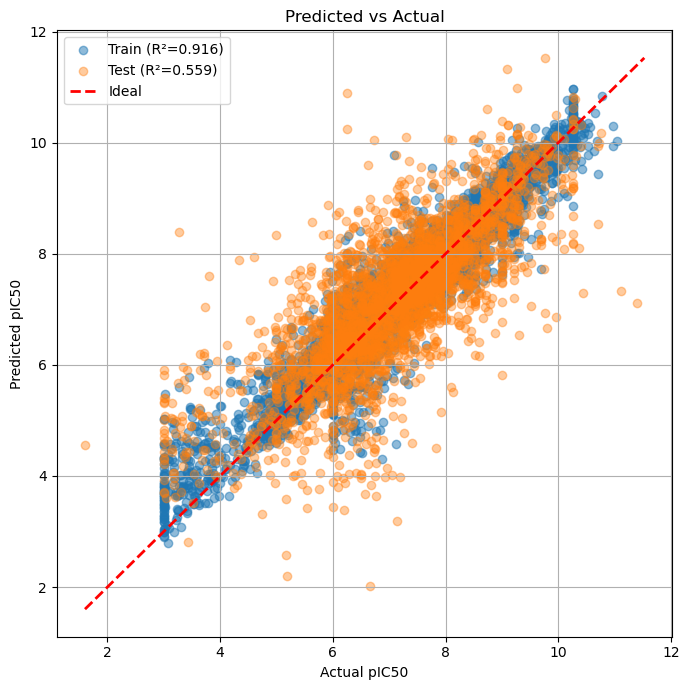

In [129]:
plt.figure(figsize=(7,7))

# Training set
plt.scatter(
    train_targets,
    train_preds,
    alpha=0.5,
    color="tab:blue",
    label=f"Train (R²={train_r2:.3f})"
)

# Test set
plt.scatter(
    test_targets,
    test_preds,
    alpha=0.4,
    color="tab:orange",
    label=f"Test (R²={test_r2:.3f})"
)

# Ideal line
min_val = min(
    train_targets.min(), train_preds.min(),
    test_targets.min(), test_preds.min()
)
max_val = max(
    train_targets.max(), train_preds.max(),
    test_targets.max(), test_preds.max()
)

plt.plot([min_val, max_val], [min_val, max_val],
         'r--', linewidth=2, label='Ideal')

plt.xlabel("Actual pIC50")
plt.ylabel("Predicted pIC50")
plt.title("Predicted vs Actual")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()